In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
from torchvision import models
import torchvision.models as models
import torch.nn as nn
import matplotlib.ticker as ticker
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ToTensor：画像のグレースケール化（RGBの0~255を0~1の範囲に正規化）、Normalize：Z値化（RGBの平均と標準偏差を0.5で決め打ちして正規化）
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

BATCH_SIZE = 32
LEARNING_RATE = 0.01
EPOCHS = 200

#データをダウンロード
"""
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
"""
train_dataset = datasets.MNIST(root = "./data", train = True, transform = transforms.Compose([transforms.ToTensor()]), download = True)
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 2, persistent_workers=True)

In [7]:
#NFG_SVRG
class NFG_SVRG_SGD(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p) # prev_aを'a'のクローンとして初期化

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_p'] = torch.clone(p).detach() # prev_pの初期値はパラメータ
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                # 補正勾配を更新
                v = grad - prev_grad + prev_a

                # パラメータを更新
                p.sub_(v, alpha = lr)
                state["t"] += 1

        return loss


model = models.resnet18(weights=None)
"""
# CIFAR用に変更
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(512, 10)
model = model.to(device)
"""
model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()
model.fc = nn.Linear(512, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = NFG_SVRG_SGD(model.parameters(), lr = LEARNING_RATE)

NFG_train_loss_x = []
NFG_train_loss = []
fg_count = 0

for epoch in range(EPOCHS):
    print(f"epoch; {epoch + 1}")
    model.train()
    train_loss = 0

    optimizer.init_epoch()

    for X, Y in tqdm(train_loader):
        X, Y = X.to(device), Y.to(device)

        optimizer.culc_prev_grads(model, X, Y, criterion)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, Y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    fg_count += 2

    NFG_train_loss_x.append(fg_count)
    NFG_train_loss.append(train_loss / len(train_loader))
    print(f"Loss: {train_loss / len(train_loader):.6f}")

    if fg_count >= 200:
        break

epoch; 1


100%|██████████| 1875/1875 [00:54<00:00, 34.61it/s]


Loss: 0.727814
epoch; 2


100%|██████████| 1875/1875 [00:56<00:00, 33.36it/s]


Loss: 0.379587
epoch; 3


...

Loss: 0.002128
epoch; 99


100%|██████████| 1875/1875 [00:55<00:00, 33.61it/s]


Loss: 0.002827
epoch; 100


100%|██████████| 1875/1875 [00:56<00:00, 33.06it/s]


Loss: 0.004827


batchsize: 32
lr: 0.01 固定
EPOCHS: 200


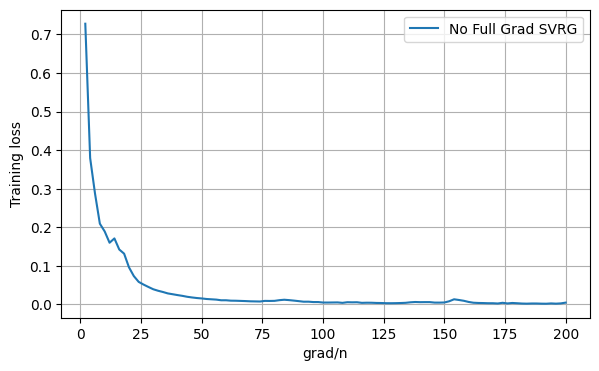

In [9]:
print('batchsize:', BATCH_SIZE)
print('lr:', LEARNING_RATE, '固定')
print('EPOCHS:', EPOCHS)

fig = plt.figure(figsize = (15, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(NFG_train_loss_x, NFG_train_loss, label = "No Full Grad SVRG")
ax.set_xlabel("grad/n")
ax.set_ylabel("Training loss")
ax.grid()
ax.legend()